# Подготовка данных

Буду сравнивать качество работы моделей RuadaptQwen3-4B и Qwen3.5-4B на задаче named entity recognition. В качестве датасета буду использовать wikiann. Загрузка датасета:

In [2]:
from datasets import load_dataset

dataset = load_dataset("wikiann", "ru")

README.md: 0.00B [00:00, ?B/s]

ru/validation-00000-of-00001.parquet:   0%|          | 0.00/809k [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Посмотрю, какие в датасете есть категории.

In [3]:
dataset['test'].features['ner_tags']

List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']))

Посмотрю пример данных в датасете.

In [4]:
dataset['test'][7777]

{'tokens': ['В', 'его', 'честь', 'назван', 'кратер', 'на', 'Луне', '.'],
 'ner_tags': [0, 0, 0, 0, 5, 6, 6, 0],
 'langs': ['ru', 'ru', 'ru', 'ru', 'ru', 'ru', 'ru', 'ru'],
 'spans': ['LOC: кратер на Луне']}

Итак, в датасете 6 типов сущностей, каждой соответствует номер от 1 до 6 (и O - не именованная сущность). Для этого сделаю мапинг в обе стороны.

In [5]:
label_feature = dataset["train"].features["ner_tags"].feature

id2label = dict(enumerate(label_feature.names))
label2id = {v: k for k, v in id2label.items()}

for i, name in id2label.items():
    print(i, "->", name)

0 -> O
1 -> B-PER
2 -> I-PER
3 -> B-ORG
4 -> I-ORG
5 -> B-LOC
6 -> I-LOC


Так как в датасете много строк, для оценки моделей возьму только первые 200.

In [6]:
test_data = dataset["test"].select(range(200))

Для того, чтобы модель точно выводила нужное количество тэгов, воспользуюсь библиотеками Pydantic и outlines для Structured Output (так как количество токенов в каждом предложении разное, под каждое новое предложение надо создавать свою схему и промпт).

In [ ]:
!pip install outlines
import outlines
from pydantic import BaseModel, Field, conint, conlist, create_model

tag_type = conint(ge=0, le=6)

def build_schema(n_tokens):
    return create_model(
        "TokenTags",
        tags=(
            conlist(tag_type, min_length=n_tokens, max_length=n_tokens),
            Field(...)
        )
    )

Составлю промпт для моделей. Добавлю в него пару примеров для few-shot.

In [8]:
def make_prompt(tokens):
    token_lines = "\n".join(f"{i}: {token}" for i, token in enumerate(tokens))
    return (
        "Ты решаешь задачу NER для русского текста.\n"
        "Нужно присвоить каждому токену ровно один тег.\n\n"
        "Используй только такие id:\n"
        "0 = O\n"
        "1 = B-PER\n"
        "2 = I-PER\n"
        "3 = B-ORG\n"
        "4 = I-ORG\n"
        "5 = B-LOC\n"
        "6 = I-LOC\n\n"
        "Правила:\n"
        "- количество тегов должно быть ровно равно количеству токенов;\n"
        "- порядок тегов должен совпадать с порядком токенов;\n"
        "- если токен не является частью именованной сущности, ставь 0;\n"
        "- используй BIO-разметку корректно.\n\n"
        "Примеры:\n"
        "['Компания', 'Apple', 'представила', 'iPhone', 'в', 'Калифорнии'] -> 0 3 0 0 0 5\n"
        "['Президент', 'России', 'Владимир', 'Путин', 'выступил', 'в', 'Нижнем', 'Новгороде'] -> 0 5 1 2 0 0 5 6\n\n"
        f"Теперь разметь следующий список токенов. Нужно вернуть ровно {len(tokens)} тегов.\n"
        "Токены:\n"
        f"{token_lines}"
    )

def parse_result(result):
    if isinstance(result, str):
        return json.loads(result)["tags"]
    if hasattr(result, "tags"):
        return list(result.tags)
    if isinstance(result, dict):
        return result["tags"]
    raise ValueError("Не удалось распарсить ответ модели")

Код для предсказания NER-тэгов для одного предложения. В случае неправильного вывода модели будет посылаться тот же самый запрос еще раз (до 10 повторений).

In [9]:
def predict_one(example, model, tokenizer, max_retries=10):
    tokens = example["tokens"]
    schema = build_schema(len(tokens))
    messages = [
        {
            "role": "user",
            "content": make_prompt(tokens)
        }
    ]
    try:
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )
    except TypeError:
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

    for _ in range(max_retries):
        try:
            result = model(
                prompt,
                output_type=schema,
                max_new_tokens=len(tokens) * 4 + 20,
                temperature=0.0,
                do_sample=False
            )
            tags = parse_result(result)
            if len(tags) == len(tokens) and all(isinstance(x, int) and 0 <= x <= 6 for x in tags):
                return tags
        except Exception:
            pass
    return [0] * len(tokens)

### Функция оценки качества

В качестве меры качества буду использовать F1-меру. По формуле:

$$
F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$$

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

В таком случае при макроусреднении по всем тэгам получится:

$$
F1_{macro} = \frac{1}{K} \sum_{i=1}^{K} F1_i
$$

In [10]:
def f1(y_true, y_pred, labels):
    f1_scores = []
    per_label_scores = {}

    for label in labels:
        tp = sum((yt == label and yp == label) for yt, yp in zip(y_true, y_pred))
        fp = sum((yt != label and yp == label) for yt, yp in zip(y_true, y_pred))
        fn = sum((yt == label and yp != label) for yt, yp in zip(y_true, y_pred))

        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

        per_label_scores[label] = {
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
        f1_scores.append(f1)

    macro_f1 = sum(f1_scores) / len(f1_scores)
    return macro_f1, per_label_scores

Код для оценки модели:

In [11]:
def evaluate_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

    hf_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype="auto",
        device_map="auto",
        trust_remote_code=True
    )
    hf_model.config.pad_token_id = tokenizer.eos_token_id
    hf_model.eval()

    model = outlines.from_transformers(hf_model, tokenizer) # outlines для SO

    all_true = []
    all_pred = []

    for example in tqdm(test_data, desc=model_name):
        pred_tags = predict_one(example, model, tokenizer)
        true_tags = example["ner_tags"]

        all_true.extend(true_tags)
        all_pred.extend(pred_tags)

    macro_f1, per_label_scores = f1(all_true, all_pred, labels=list(id2label.keys()))

    cm = confusion_matrix(all_true, all_pred, labels=list(id2label.keys()))

    del model
    del hf_model
    del tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "macro_f1": macro_f1,
        "per_label_scores": per_label_scores,
        "y_true": all_true,
        "y_pred": all_pred,
        "confusion_matrix": cm
    }


In [12]:
model_names = {
    "Qwen3.5-4B": "Qwen/Qwen3.5-4B",
    "RuadaptQwen3-4B": "RefalMachine/RuadaptQwen3-4B-Instruct"
}

In [13]:
import gc
import json
import numpy as np
import torch
import outlines
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from pydantic import BaseModel, Field, conint, conlist, create_model
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
results = {}

for short_name, model_name in model_names.items():
    results[short_name] = evaluate_model(model_name)

Результаты:

In [15]:
for model_name, result in results.items():
    print(model_name)
    print("macro F1 =", round(result["macro_f1"], 4))
    for label_id, scores in result["per_label_scores"].items():
        print(
            id2label[label_id],
            "precision =", round(scores["precision"], 4),
            "recall =", round(scores["recall"], 4),
            "f1 =", round(scores["f1"], 4)
        )
    print()

Qwen3.5-4B
macro F1 = 0.2571
O precision = 0.6147 recall = 0.9736 f1 = 0.7536
B-PER precision = 0.2642 recall = 0.1609 f1 = 0.2
I-PER precision = 0.6341 recall = 0.1503 f1 = 0.243
B-ORG precision = 0.2632 recall = 0.2027 f1 = 0.229
I-ORG precision = 0.5 recall = 0.0067 f1 = 0.0132
B-LOC precision = 0.4359 recall = 0.2237 f1 = 0.2957
I-LOC precision = 0.5 recall = 0.0351 f1 = 0.0656

RuadaptQwen3-4B
macro F1 = 0.2937
O precision = 0.6951 recall = 0.8252 f1 = 0.7546
B-PER precision = 0.3909 recall = 0.8851 f1 = 0.5423
I-PER precision = 0.4528 recall = 0.2775 f1 = 0.3441
B-ORG precision = 0.119 recall = 0.1351 f1 = 0.1266
I-ORG precision = 0.2093 recall = 0.06 f1 = 0.0933
B-LOC precision = 0.2128 recall = 0.1316 f1 = 0.1626
I-LOC precision = 0.2 recall = 0.0175 f1 = 0.0323



Помимо F1-меры можно посмотреть на матрицы ошибок моделей.

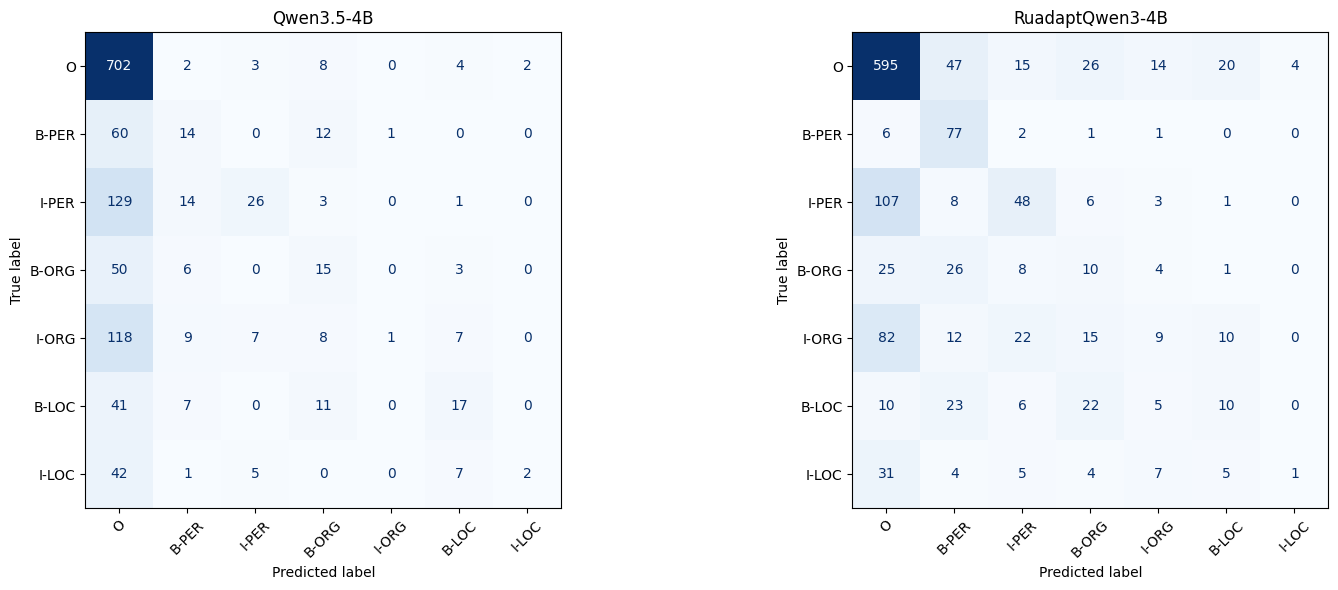

In [16]:
fig, axes = plt.subplots(1, len(results), figsize=(16, 6))

for ax, (model_name, result) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=[id2label[i] for i in range(len(id2label))]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format="d",
        colorbar=False
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## Выводы

Итоговые метрики:

Qwen3.5: $F_1= 0.2571$

RuadaptQwen3: $F_1=0.2937$

Обе модели справляются с задачей неважно. RuadaptQwen3-4B работает лучше,  вероятно потому, что она дообучалась на русскоязычных данных, что улучшает обработку русских именованных сущностей и морфологии.

Однако обе модели являются генеративными LLM, не обучавшимися под задачу классификации токенов, поэтому для задачи NER лучше использовать encoder-модели по типу BERT.